# Embedded ML - Lab 2.2: TensorFlow Lite

In this lab you will learn the basics of TensorFlow Lite, a complement of TensorFlow that allows you to optimize and run models on constrained devices. It provides a much lighter runtime than TensorFlow but it only supports a subset of the tools available in full TensorFlow.

In this lab you might be given some helper functions but you are expected to write most of the code and be able to explain it at a high level of abstraction and also to modify any part of it.

### Learning outcomes


* Explain the basic concepts associated with TensorFlow Lite
* Develop applications following the basic TensorFlow Lite workflow
* Implement post-training quantization using TensorFlow Lite tools

### TensorFlow Lite workflow
After having built a TensorFlow model, you can convert it to the TensorFlow Lite representation. Then you can run it with the TensorFlow Lite interpreter on your development environment before exporting it and copying it to the target device.

To run the model with TensorFlow Lite you should load the model to the TensorFlow Lite interpreter, allocate the input/output tensors, pass the input data and finally run inference. Notice that TensorFlow Lite API calls are different from those of TensorFlow.

In this part of the assignment, you should create and train a simple model (e.g. a one-neuron network) with TensorFlow and then save it. Then follow the TensorFlow Lite workflow until you are able to run inference and validate the outputs.

In [ ]:
#### TENSORFLOW BASIC WORKFLOW
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
outputs = np.array([0,1,1,0])

# Create the model
model = Sequential([
    Dense(2,activation = 'relu',input_shape=(2,)),
    Dense(1,activation = 'sigmoid')
])

# Compile the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
    loss = 'MSE',
    metrics = ['accuracy']
)

# Train the model
model.fit(inputs,outputs,epochs = 100,verbose = 0)

In [ ]:
model.evaluate(inputs,outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 1.0000 - loss: 5.3327e-04


[0.000533268554136157, 1.0]

In [ ]:
# Save the model to a file
model.save('model.keras')

In [ ]:
model = tf.keras.models.load_model('model.keras')

# Convert the Keras model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open('xor_model.tflite', 'wb') as f:
  f.write(tflite_model)

# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the model with sample data
input_shape = input_details[0]['shape']
input_data = np.array([[0, 0]], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

# The output is a numpy array.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Input: {input_data}, Output: {output_data}")

input_data = np.array([[0, 1]], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Input: {input_data}, Output: {output_data}")

input_data = np.array([[1, 0]], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Input: {input_data}, Output: {output_data}")

input_data = np.array([[1, 1]], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Input: {input_data}, Output: {output_data}")


Saved artifact at '/tmp/tmpftjbmtc5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136916407932240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136916407931472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136916407939728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136916407940112: TensorSpec(shape=(), dtype=tf.resource, name=None)
Input: [[0. 0.]], Output: [[0.03073844]]
Input: [[0. 1.]], Output: [[0.9855203]]
Input: [[1. 0.]], Output: [[0.9941939]]
Input: [[1. 1.]], Output: [[0.03073844]]


### Vision model with TensorFlow Lite

In this part of the assignment, you should import a small pre-trained model for a vision application that takes at most 1 MB. Then you should follow the TensorFlow Lite workflow until you are able to run inference and obtain the same results as with TensorFlow.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Pre-process input dataset
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels,test_labels = to_categorical(train_labels, num_classes=10), to_categorical(test_labels, num_classes=10)
# Create the CNN model
model_conv = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(16, (3, 3), activation='relu'),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
 ])
# Compile the CNN model
model_conv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_conv.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels),verbose='0')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


In [ ]:
#model = tf.keras.models.load_model('model.keras')
# Converter the keras model to tensorflow lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model_conv)
tflite_model = converter.convert()

#save model
with open('convolution_model.tflite','wb') as f:
  f.write(tflite_model)

#Load the tensorflow lite model and allocate tensors
interpreter = tf.lite.Interpreter(model_content = tflite_model)
interpreter.allocate_tensors()

#Get Input and Output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the model with test data
input_data = np.expand_dims(test_images[0], axis=0)
input_data = np.expand_dims(input_data, axis=-1)
input_data = np.array(input_data, dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

# Get network's output
output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Output: {np.argmax(output_data)}")

print(f"Label: {np.argmax(test_labels[0])}")

Saved artifact at '/tmp/tmp4rz120wh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136919332024208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332024400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332026896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332025360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919331243600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1369193312430

### Post-training quantization
Finally, in this part of the assignment you should activate quantization and convert the model again. Compare model size and accuracy of the compressed TensorFlow Lite model by using various configurations (investigate how) and against the uncompressed baseline.

In [ ]:
model_conv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,112 (414.50 KB)

 Trainable params: 35,370 (138.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,742 (276.34 KB)

In [ ]:
def evaluate_model(interpreter, test_images, test_labels):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    predictions = []
    for i in range(len(test_images)):
        input_data = np.expand_dims(test_images[i], axis=0)
        if len(input_data.shape) == 3: # Add channel dimension for CNN
             input_data = np.expand_dims(input_data, axis=-1)
        input_data = np.array(input_data, dtype=input_details[0]['dtype'])
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(np.argmax(output_data))
    accuracy = np.mean(predictions == np.argmax(test_labels, axis=1))
    return accuracy

# Convert the Keras model to TensorFlow Lite format with quantization

# Default dynamic range quantization
converter_quant_dr = tf.lite.TFLiteConverter.from_keras_model(model_conv)
converter_quant_dr.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_quant_dr = converter_quant_dr.convert()

# Save the quantized TFLite model (dynamic range)
with open('convolution_model_quant_dr.tflite', 'wb') as f:
    f.write(tflite_model_quant_dr)

# Post-training integer quantization (requires a representative dataset)
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(train_images).batch(1).take(100):
        # Add channel dimension to the input data and cast to float32
        yield [tf.cast(tf.expand_dims(input_value, axis=-1), tf.float32)]

converter_quant_int = tf.lite.TFLiteConverter.from_keras_model(model_conv)
converter_quant_int.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant_int.representative_dataset = representative_data_gen
# Ensure the input and output tensors are integers
converter_quant_int.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_model_quant_int = converter_quant_int.convert()

# Save the quantized TFLite model (integer)
with open('convolution_model_quant_int.tflite', 'wb') as f:
    f.write(tflite_model_quant_int)

# Post-training float16 quantization
converter_quant_fp16 = tf.lite.TFLiteConverter.from_keras_model(model_conv)
converter_quant_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant_fp16.target_spec.supported_types = [tf.float16]

tflite_model_quant_fp16 = converter_quant_fp16.convert()

# Save the quantized TFLite model (float16)
with open('convolution_model_quant_fp16.tflite', 'wb') as f:
    f.write(tflite_model_quant_fp16)

# --- Compare model size and accuracy ---

# Get file sizes
import os # Import os module

size_uncompressed = os.path.getsize('convolution_model.tflite')
size_quant_dr = os.path.getsize('convolution_model_quant_dr.tflite')
size_quant_int = os.path.getsize('convolution_model_quant_int.tflite')
size_quant_fp16 = os.path.getsize('convolution_model_quant_fp16.tflite')

# Evaluate accuracy
print("\nEvaluating models...")

# Evaluate uncompressed model
interpreter_uncompressed = tf.lite.Interpreter(model_content=tflite_model)
interpreter_uncompressed.allocate_tensors()
accuracy_uncompressed = evaluate_model(interpreter_uncompressed, test_images, test_labels)

# Evaluate dynamic range quantized model
interpreter_quant_dr = tf.lite.Interpreter(model_content=tflite_model_quant_dr)
interpreter_quant_dr.allocate_tensors()
accuracy_quant_dr = evaluate_model(interpreter_quant_dr, test_images, test_labels)

# Evaluate integer quantized model
interpreter_quant_int = tf.lite.Interpreter(model_content=tflite_model_quant_int)
interpreter_quant_int.allocate_tensors()
accuracy_quant_int = evaluate_model(interpreter_quant_int, test_images, test_labels)

# Evaluate float16 quantized model
interpreter_quant_fp16 = tf.lite.Interpreter(model_content=tflite_model_quant_fp16)
interpreter_quant_fp16.allocate_tensors()
accuracy_quant_fp16 = evaluate_model(interpreter_quant_fp16, test_images, test_labels)

Saved artifact at '/tmp/tmpx0e18y28'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136919332024208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332024400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332026896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332025360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919331243600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1369193312430

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved artifact at '/tmp/tmpezzvhq9x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136919332024208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332024400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332026896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332025360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332027664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919332028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136919331243600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1369193312430

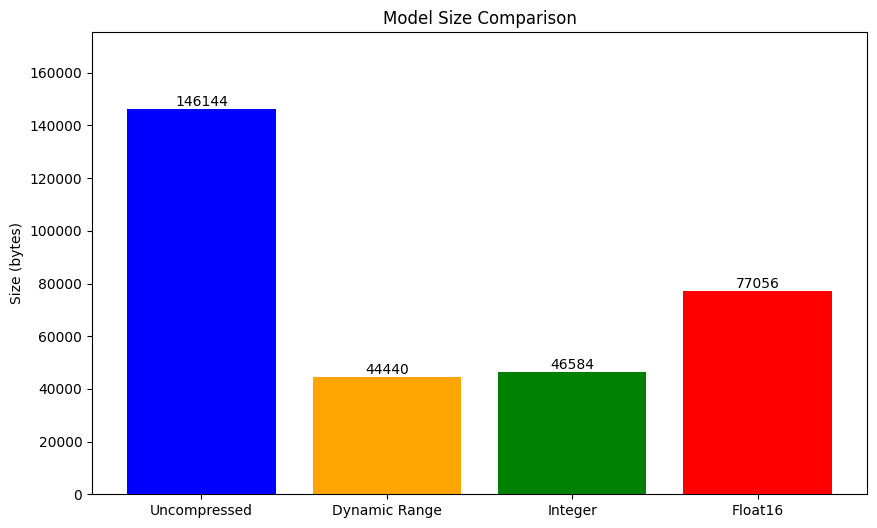

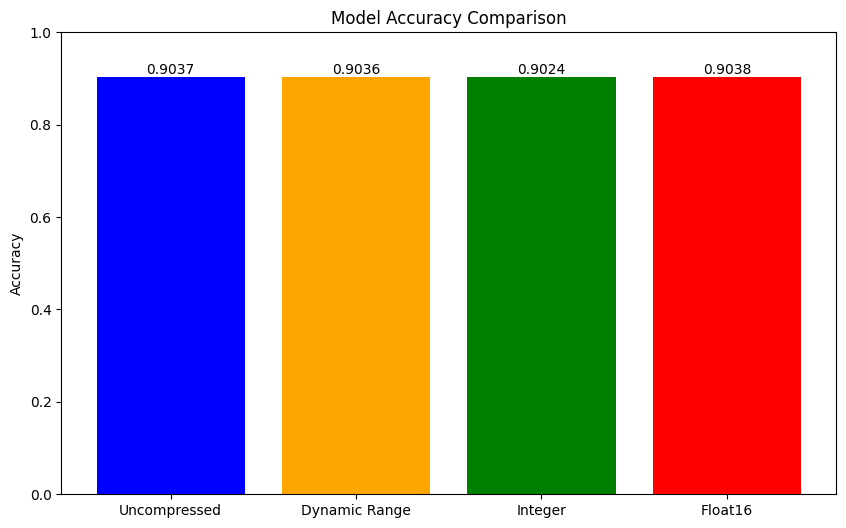

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for plotting
data = {
    'Model': ['Uncompressed', 'Dynamic Range', 'Integer', 'Float16'],
    'Size (bytes)': [size_uncompressed, size_quant_dr, size_quant_int, size_quant_fp16],
    'Accuracy': [accuracy_uncompressed, accuracy_quant_dr, accuracy_quant_int, accuracy_quant_fp16]
}

df = pd.DataFrame(data)

# Plotting Size
plt.figure(figsize=(10, 6))
bars_size = plt.bar(df['Model'], df['Size (bytes)'], color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Size (bytes)')
plt.title('Model Size Comparison')
plt.ylim(0, max(df['Size (bytes)']) * 1.2) # Add some space above the tallest bar

# Add exact values on the bars for Size
for bar in bars_size:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.0f}', va='bottom', ha='center') # .0f for integer size

plt.show()

# Plotting Accuracy
plt.figure(figsize=(10, 6))
bars_accuracy = plt.bar(df['Model'], df['Accuracy'], color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0) # Accuracy is between 0 and 1

# Add exact values on the bars for Accuracy
for bar in bars_accuracy:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', va='bottom', ha='center') # .4f for accuracy

plt.show()
